# Intro

* Notation: C(A)
* Definition: the vector subspace spanned by the columns of A

If $a_i$ represent all matrix columns and $b_i$ represents all matrix rows, we get:

1. column space is defined by $C(A) = \{\beta_1 a_1 + \dots + \beta_n a_n : \beta_i \in \mathbb{R} \}$, i.e. $\beta_i$ any possible number, and column space is space that includes all linear combinations of column vectors.

2. row space is defined by $R(A) = \{\gamma_1 b_1 + \dots + \gamma_m b_m : \gamma_i \in \mathbb{R} \}$, i.e. $\beta_i$ any possible number, and rows space is space that includes all linear combinations of rows vectors.

$
\textbf{Column space}
\qquad\qquad
\textbf{Row space}
$

$
\begin{bmatrix}
3 & 0 \\
5 & 2 \\
1 & 2
\end{bmatrix}
\begin{bmatrix}
-1 \\
3
\end{bmatrix}
=
\begin{bmatrix}
-3 \\
1 \\
5
\end{bmatrix}
\qquad\qquad
\begin{bmatrix}
-1 & 0 & 3
\end{bmatrix}
\begin{bmatrix}
3 & 0 \\
5 & 2 \\
1 & 2
\end{bmatrix}
=
\begin{bmatrix}
0 & 6
\end{bmatrix}
$

If we want to find vector from column space we need to multiply vector with coefficients by matrix, where vector with coefficients is on the right side - then the output is a linear combination of columns and vector of coefficients, i.e. output is in column space.

If we want to find a vector from row space we need to multiply vector with coefficients by matrix, where vector with coefficients is on the left side - then the output is a linear combination of rows and vector of coefficients, i.e. output is in row space.

$$ A\beta \rightarrow \text{column space} $$
$$ \gamma A \rightarrow \text{row space} $$

# Code

## Column Space

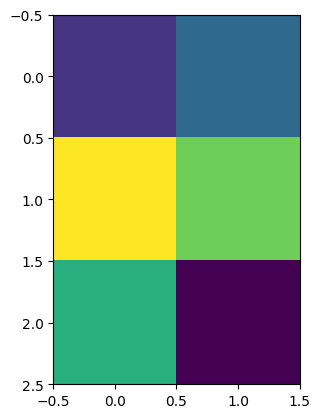

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

m = 3
n = 2

matrix = np.random.randn(m,n)

plt.imshow(matrix)
plt.show()

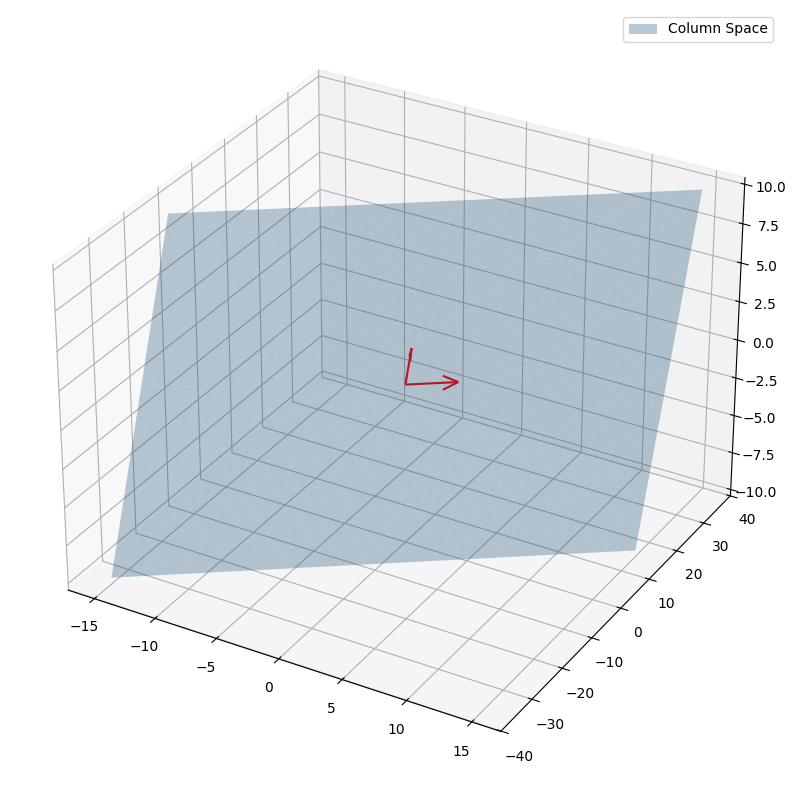

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

matrix = np.array([
    [3, 0],
    [5, 2],
    [0, 2]
])

c1 = matrix[:, 0]
c2 = matrix[:, 1]

# ----- column space in R^3 -----
b1 = np.linspace(-5, 5, 50)
b2 = np.linspace(-5, 5, 50)
B1, B2 = np.meshgrid(b1, b2)

Xc = B1 * c1[0] + B2 * c2[0]
Yc = B1 * c1[1] + B2 * c2[1]
Zc = B1 * c1[2] + B2 * c2[2]

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(Xc, Yc, Zc, alpha=0.3, label = 'Column Space')
ax.quiver(0,0,0,c1[0],c1[1],c1[2], color='r')
ax.quiver(0,0,0,c2[0],c2[1],c2[2], color='r')


plt.legend()
plt.show()

## Row Space

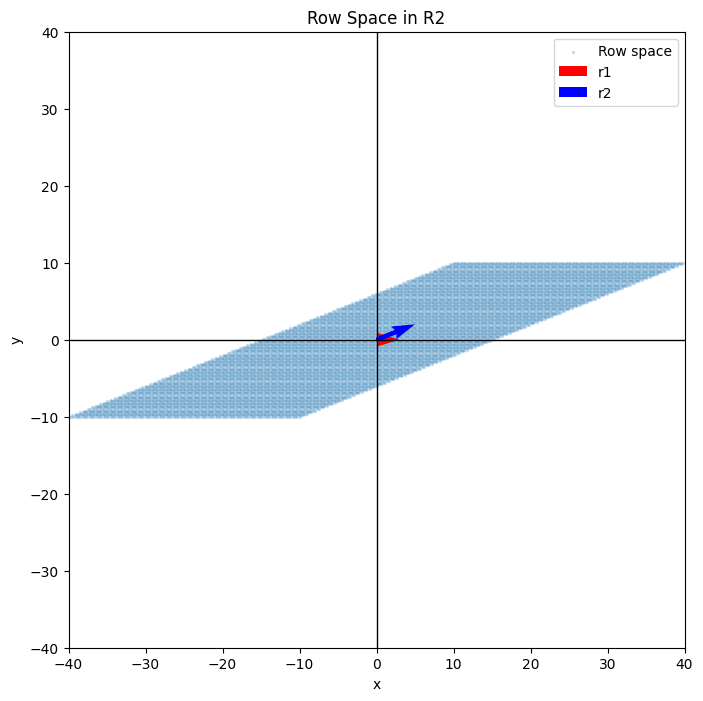

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [3, 0],
    [5, 2],
    [0, 2]
])

# rows: vectors in R2
r1 = A[0, :]  # [3, 0]
r2 = A[1, :]  # [5, 2]

g1 = np.linspace(-5, 5, 100)
g2 = np.linspace(-5, 5, 100)
G1, G2 = np.meshgrid(g1, g2)

# row space = all combinations gamma1*r1 + gamma2*r2
X = G1 * r1[0] + G2 * r2[0]
Y = G1 * r1[1] + G2 * r2[1]

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X, Y, s=2, alpha=0.2, label="Row space")

ax.quiver(0, 0, r1[0], r1[1], angles="xy", scale_units="xy", scale=1, color="r", label="r1")
ax.quiver(0, 0, r2[0], r2[1], angles="xy", scale_units="xy", scale=1, color="b", label="r2")

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

ax.set_aspect("equal")
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Row Space in R2")
ax.legend()

plt.show()

Important quesiton in linear algebra: $v \in C(A)$?

* Yes $\rightarrow$ What coefficients?
* No $\rightarrow$ How close is to $C(A)$?

# Null Space of a Matrix

Null space of a matrix are all vectors without vector full of 0's which when multiplied by a matrix return just zeros.

$N(A)$: The set of all vectors $\{v\}$ such that $Av = 0\;and\;v\neq 0$

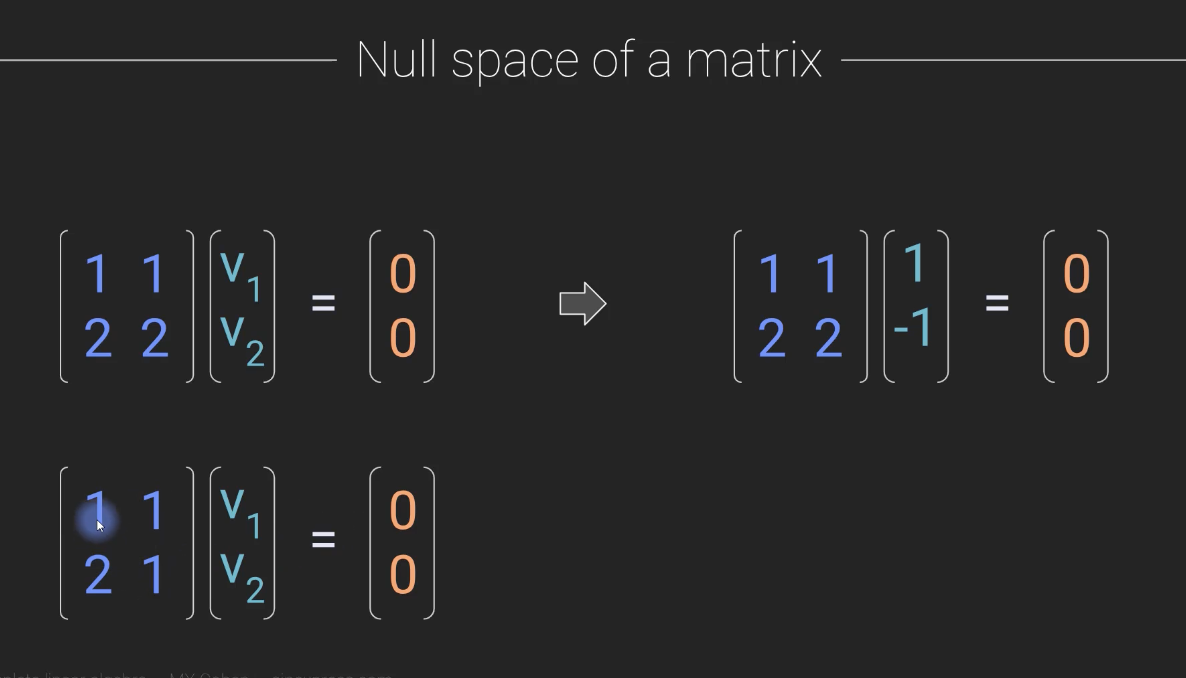

For some matrixes we can have infinite vectors that belong to null space as below.

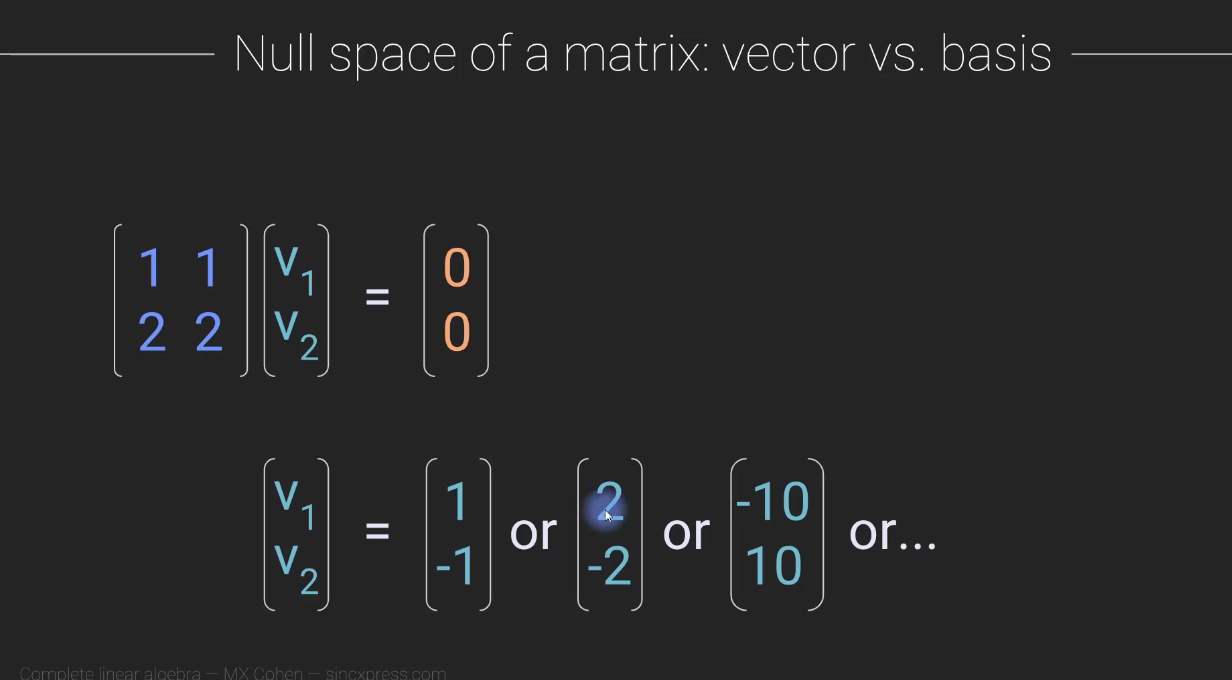

Then we take just a basis vector and define $\lambda$ as entire subspace that scaled by given basis vector creates null space vector.

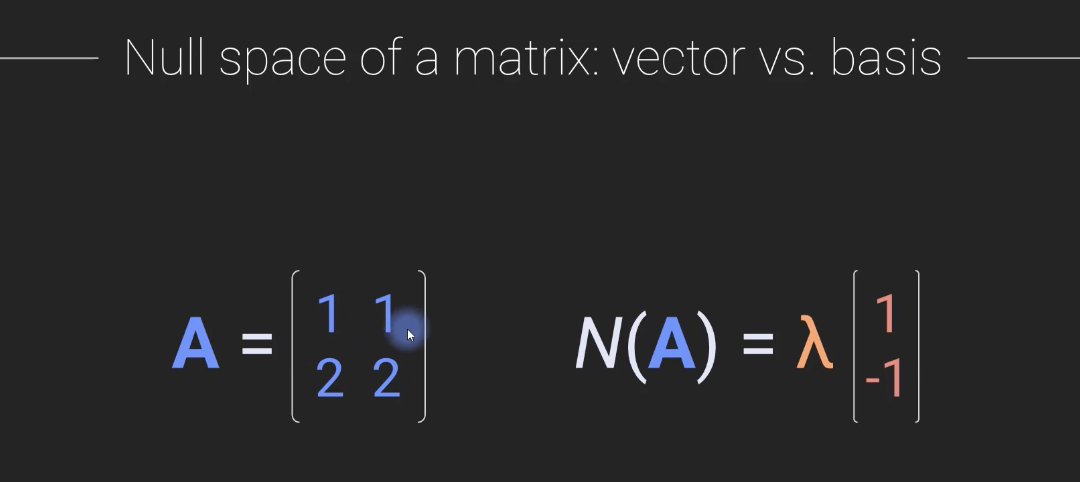

What is important matrix with null space creates linearly dependent set, so [1,2], [1,2] while matrix without null space creates linearly independent set, so [1,2],[1,1].



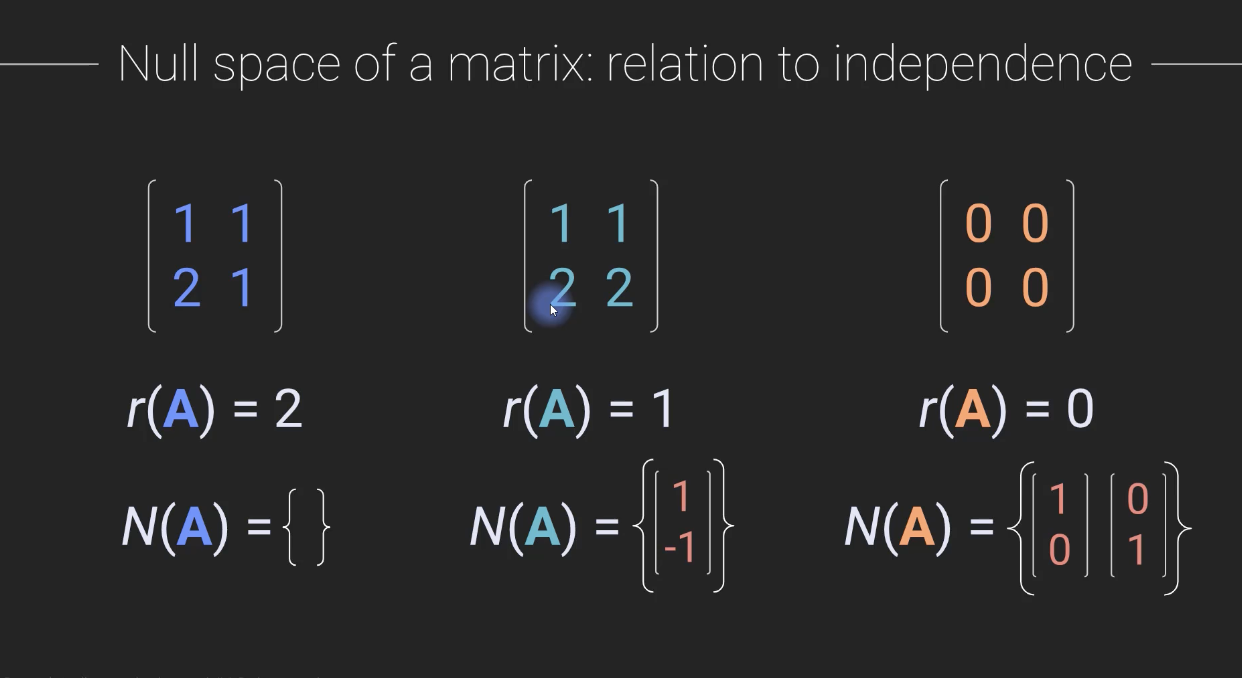

Null space is the space of vectors that are transformed by a matrix into the zero vector.

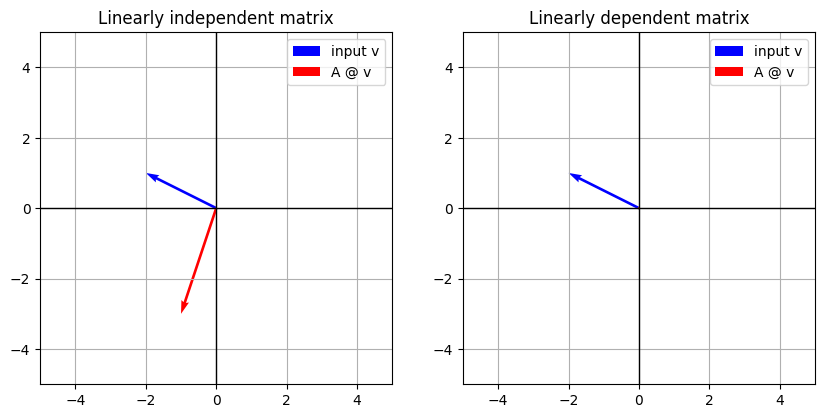

lin_ind_mat @ vector = [-1 -3]
lin_dep_mat @ vector = [0 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lin_ind_mat = np.array([[1,1],
                        [2,1]])

lin_dep_mat = np.array([[1,2],
                        [1,2]])

vector = np.array([-2, 1])   # null vector for lin_dep_mat

v_ind = lin_ind_mat @ vector
v_dep = lin_dep_mat @ vector

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

def plot_transform(ax, A, v, Av, title):
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='b', label='input v')
    ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1, color='r', label='A @ v')

    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title(title)
    ax.legend()

plot_transform(axs[0], lin_ind_mat, vector, v_ind, "Linearly independent matrix")
plot_transform(axs[1], lin_dep_mat, vector, v_dep, "Linearly dependent matrix")

plt.show()

print("lin_ind_mat @ vector =", v_ind)
print("lin_dep_mat @ vector =", v_dep)

## Left Null-Space

* Left null space is perpendicular to column space:

$$ N(A^T) = Col(A)^\perp $$

**Reminder about dot product**

$$c = |a||b|cos(\theta_{ab})$$

Orthogonal means $\theta = 90^o$ and $c$ then is exactly 0.

In [ ]:
np.allclose(np.cos(np.pi/2),0)

True

So, if $v$ is orthogonal to one column $a_1$ from matrix $M$ that would mean:

$$ v^T a_1 = 0 $$

Therefore, if vector $v$ is orthogonal to EVERY column $a_1, \dots, a_n$ in matrix $M$ then:

$$ v^T (\alpha_1 a_1 + \dots + \alpha_n a_n) = 0 $$

where $\alpha_i$ are any scalars.

And that is the definition of **Null Space**.

$$ A^Tv = 0 $$

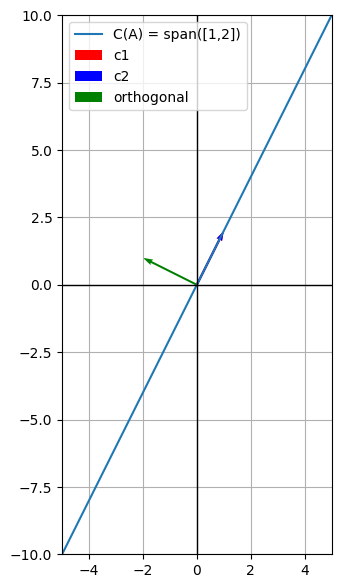

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [1, 1],
    [2, 2]
])

c1 = A[:, 0]   # [1,2]
c2 = A[:, 1]   # [1,2]

# column space = all beta * [1,2]
t = np.linspace(-5, 5, 100)
X = t * c1[0]
Y = t * c1[1]

# orthogonal v
a = np.array([1, 2])
orth = np.array([-a[1], a[0]])  # [-2, 1]
orth

fig, ax = plt.subplots(figsize=(7,7))

# column space line
ax.plot(X, Y, label="C(A) = span([1,2])")

# columns as vectors
ax.quiver(0, 0, c1[0], c1[1], angles="xy", scale_units="xy", scale=1, color="r", label="c1")
ax.quiver(0, 0, c2[0], c2[1], angles="xy", scale_units="xy", scale=1, color="b", label="c2")
ax.quiver(0, 0, orth[0], orth[1], angles = 'xy', scale_units='xy', scale=1, color='g', label='orthogonal')

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlim(-5, 5)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

Now, orthogonal vector will give us 0, which is [-2,1]. However, in below situation:

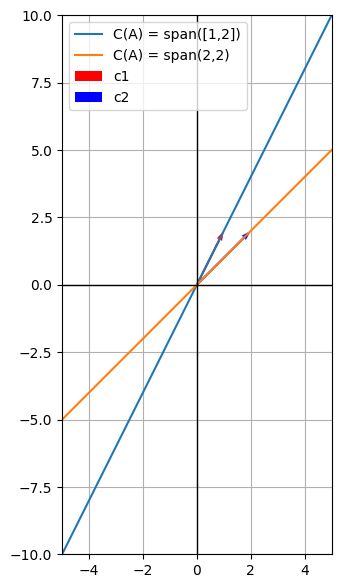

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [1, 2],
    [2, 2]
])

c1 = A[:, 0]   # [1,2]
c2 = A[:, 1]   # [1,2]

# column space = all beta * [1,2]
t = np.linspace(-5, 5, 100)
X1 = t * c1[0]
Y1 = t * c1[1]

X2 = t * c2[0]
Y2 = t * c2[1]

fig, ax = plt.subplots(figsize=(7,7))

# column space line
ax.plot(X1, Y1, label="C(A) = span([1,2])")
ax.plot(X2, Y2, label = 'C(A) = span(2,2)')

# columns as vectors
ax.quiver(0, 0, c1[0], c1[1], angles="xy", scale_units="xy", scale=1, color="r", label="c1")
ax.quiver(0, 0, c2[0], c2[1], angles="xy", scale_units="xy", scale=1, color="b", label="c2")

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlim(-5, 5)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

... we don't have 1 vector in $\mathbb{R}^2$ which will be orthogonal to both vectors. So, we don't have left null space in $\mathbb{R}^2$, due to lack of orthogonal vector to all of the column vectors in $\mathbb{R}^2$

## Null Space

* Null space is perpendicular to row space:

$$ N(A) = Row(A)^\perp $$

Null space means that if $v \perp R(A)$, so $v$ is perpendicular to the rows of $A$, then:

$$ v^T a_1^T = 0 $$

where $a_1$ is a row of $A$.

More generally:

$$ v^T(\alpha_1 a_1^T + \dots + \alpha_m a_m^T) = 0 $$

where $\alpha_i$ are any scalars and $a_i$ are rows of $A$.

Equivalently:

$$ Av = 0 $$

# Dimensions of column/row/null spaces

Dimensionality $\neq$ rank

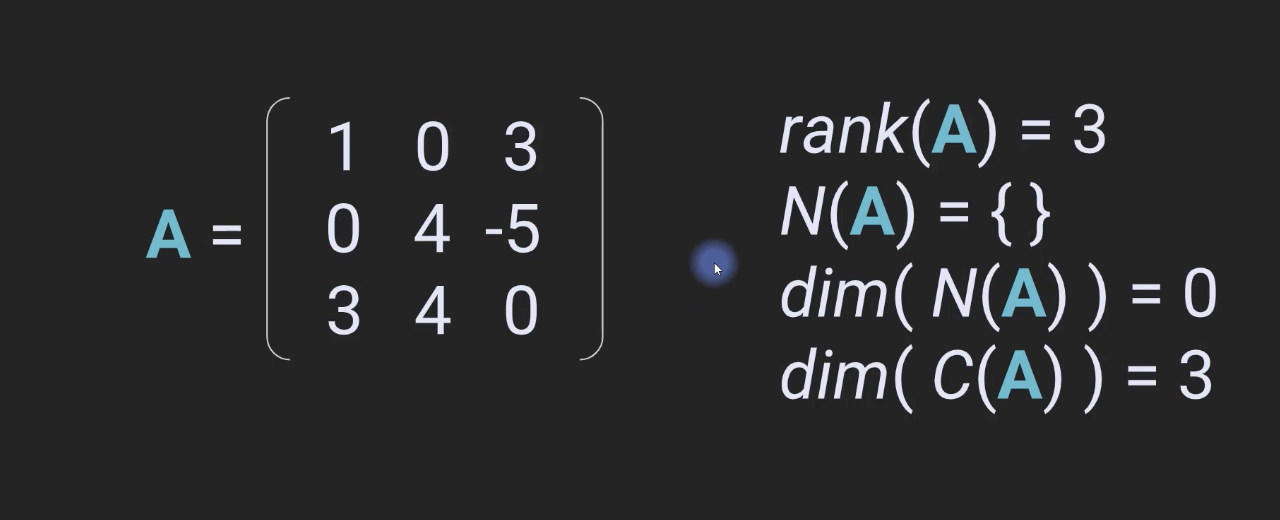

Relationship across dimensionalities

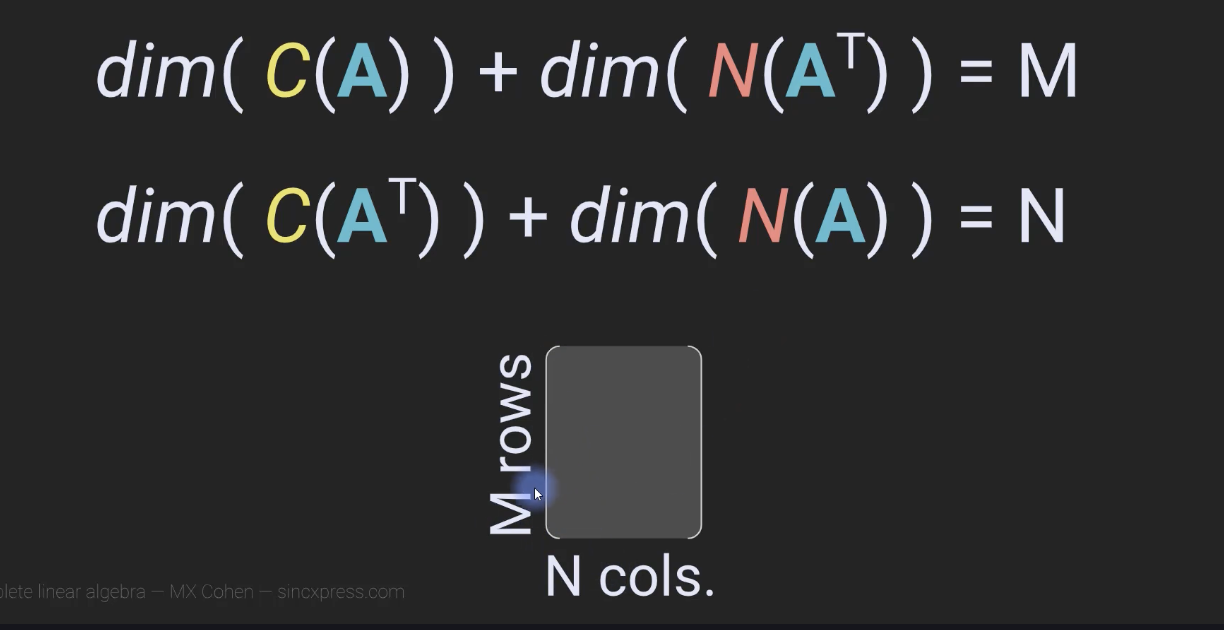

# Review

| Nazwa                         | Symbol                  | Co to jest?                                                                      | Prosto                                                    |
| ----------------------------- | ----------------------- | -------------------------------------------------------------------------------- | --------------------------------------------------------- |
| liczba wierszy                | M                       | liczba poziomych linii w macierzy                                                | ile liczb ma jedna kolumna                                |
| liczba kolumn                 | N                       | liczba pionowych linii w macierzy                                                | ile liczb ma jeden wiersz                                 |
| jedna kolumna                 | column                  | pionowy wektor z macierzy                                                        | ma M liczb                                                |
| jeden wiersz                  | row                     | poziomy wektor z macierzy                                                        | ma N liczb                                                |
| column space                  | Col(A)                  | cała przestrzeń zrobiona z kolumn                                                | wszystkie wektory, które można zbudować mieszając kolumny |
| dim column space              | dim(Col(A))             | liczba wymiarów column space                                                     | ile niezależnych kierunków dają kolumny                   |
| row space                     | Row(A)                  | cała przestrzeń zrobiona z wierszy                                               | wszystkie wektory, które można zbudować mieszając wiersze |
| dim row space                 | dim(Row(A))             | liczba wymiarów row space                                                        | ile niezależnych kierunków dają wiersze                   |
| ambient space kolumn          | ℝ^M                     | miejsce, w którym żyją kolumny                                                   | kolumna ma M liczb, więc żyje w M-wymiarowej przestrzeni  |
| ambient space wierszy         | ℝ^N                     | miejsce, w którym żyją wiersze                                                   | wiersz ma N liczb, więc żyje w N-wymiarowej przestrzeni   |
| rank                          | rank(A)                 | ile kolumn/wierszy wnosi nową informację, a nie jest kopią albo mieszanką innych | rank(A) = dim(Col(A)) = dim(Row(A))                       |
| max rank                      | min(M,N)                | jaki max rank może mieć macierz o danych wymiarach                               | rank nie może być większy niż M ani N                     |
| null space                    | Null(A) lub N(A)        | wszystkie wektory x, dla których Ax = 0                                          | kierunki „zabijane” przez macierz                         |
| dim null space                | dim(Null(A))            | liczba niezależnych kierunków w null space                                       | ile stopni swobody ma równanie Ax = 0                     |
| ambient space null space      | ℝ^N                     | miejsce, w którym żyją wektory x z Ax=0                                          | x ma N liczb, więc żyje w ℝ^N                             |
| left null space               | Null(Aᵀ)                | wszystkie wektory y, dla których Aᵀy = 0                                         | kierunki prostopadłe do wszystkich kolumn                 |
| dim left null space           | dim(Null(Aᵀ))           | liczba wymiarów left null space                                                  | ile niezależnych ograniczeń nie trafia w kolumny          |
| ambient space left null space | ℝ^M                     | miejsce, w którym żyją wektory y z Aᵀy=0                                         | y ma M liczb, więc żyje w ℝ^M                             |
| rank-nullity theorem          | rank(A)+dim(Null(A))=N  | podstawowy związek między rank i null space                                      | wszystkie kierunki wejścia = użyteczne + zabijane         |
| left rank-nullity             | rank(A)+dim(Null(Aᵀ))=M | wersja dla lewej strony                                                          | wszystkie kierunki wyjścia = użyteczne + prostopadłe      |


What is most important:

$$ \text{dim(column space) = dim(row space) = rank(A)}$$

ALWAYS

Text(0.5, 1.0, 'matrix')

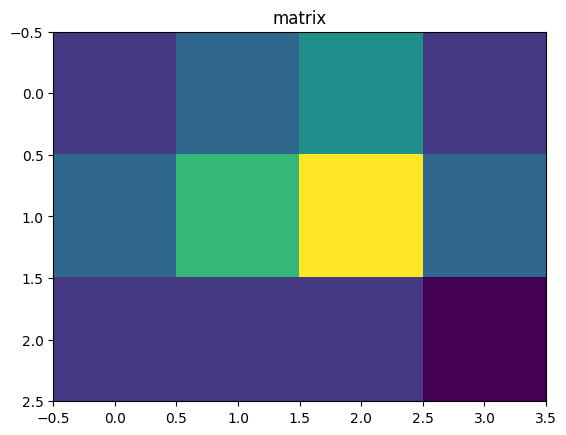

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



matrix = np.array([
    [1, 2, 3, 1],
    [2, 4, 6, 2],
    [1, 1, 1, 0]
], dtype=float)

plt.imshow(matrix)
plt.title('matrix')

## Column Space

The span of all column vectors

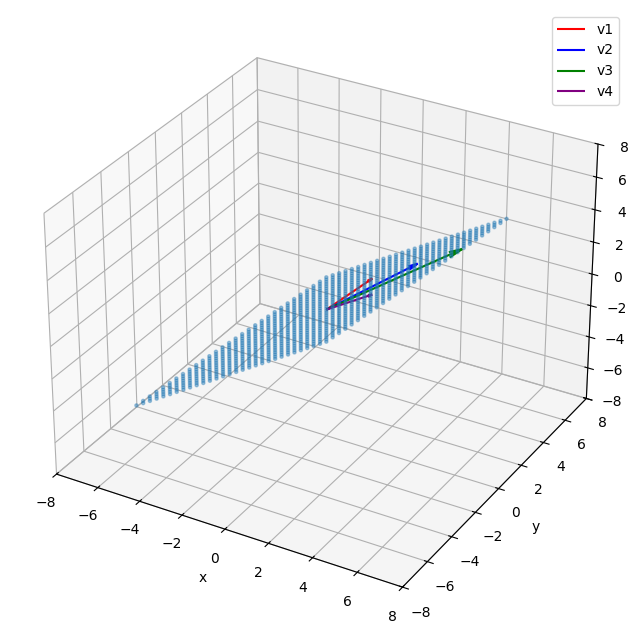

In [ ]:
v1 = matrix[:, 0]
v2 = matrix[:, 1]
v3 = matrix[:, 2]
v4 = matrix[:, 3]

s, t = np.meshgrid(
    np.linspace(-2, 2, 30),
    np.linspace(-2, 2, 30)
)

basis1 = matrix[:, 0]
basis2 = matrix[:, 3]

X = s * basis1[0] + t * basis2[0]
Y = s * basis1[1] + t * basis2[1]
Z = s * basis1[2] + t * basis2[2]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(X, Y, Z, s=5, alpha=0.4)

for v, color, label in [
    (v1, "r", "v1"),
    (v2, "b", "v2"),
    (v3, "g", "v3"),
    (v4, "purple", "v4")
]:
    ax.quiver(
        0, 0, 0,
        v[0], v[1], v[2],
        color=color,
        arrow_length_ratio=0.1,
        label=label
    )

ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_zlim(-8, 8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.legend()
plt.show()

## Column Space Dimension

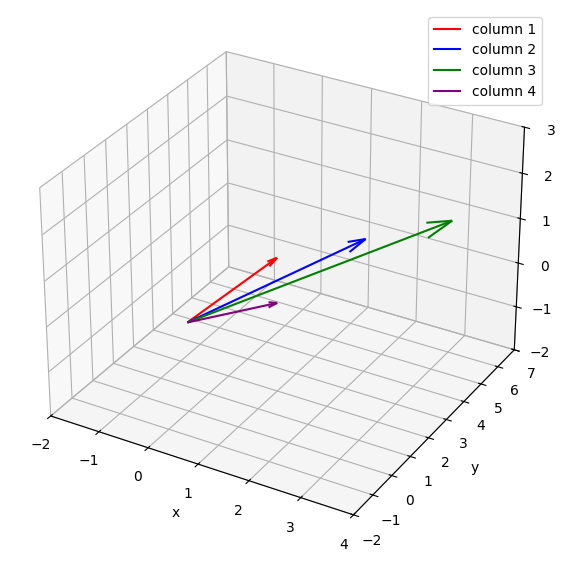

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ax = plt.figure(figsize=(7, 7)).add_subplot(projection='3d')

colors = ['r', 'b', 'g', 'purple']

for i in range(matrix.shape[1]):
    ax.quiver(
        0, 0, 0,
        matrix[0, i],
        matrix[1, i],
        matrix[2, i],
        color=colors[i],
        arrow_length_ratio=0.1,
        label=f"column {i+1}"
    )

ax.set(xlim=(-2, 4), ylim=(-2, 7), zlim=(-2, 3))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

Even though we see 4 separate arrows we have column space dimension = 2 because all the arrows live in 2d, i.e. all arrows can be created by 2 others.

In [ ]:
print('Column space dimension:', np.linalg.matrix_rank(matrix))

Column space dimension: 2


## Row Space

Span of row vectors

In [ ]:
matrix

array([[1., 2., 3., 1.],
       [2., 4., 6., 2.],
       [1., 1., 1., 0.]])

We can't normally visualize row space since it lives in $\mathbb{R}^4$

## Row Space Dimension

In [ ]:
print('Row space dimension:', np.linalg.matrix_rank(matrix.T))

Row space dimension: 2


## Null Space

All vectors for which Ax = 0

In [ ]:
from scipy.linalg import null_space

N = null_space(matrix)
N

array([[-0.55065812,  0.17351935],
       [ 0.72417747,  0.37713877],
       [-0.17351935, -0.55065812],
       [-0.37713877,  0.72417747]])

In [ ]:
test = matrix@N
test

array([[0.00000000e+00, 1.11022302e-16],
       [0.00000000e+00, 2.22044605e-16],
       [4.60742555e-15, 0.00000000e+00]])

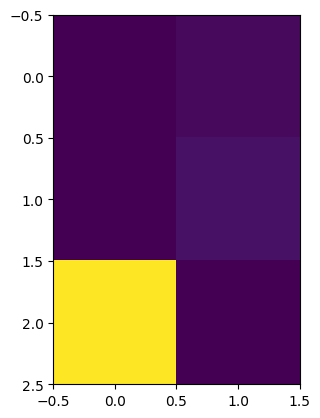

In [ ]:
plt.imshow(test)

In [ ]:
np.allclose(test,0)

True

## Left Null Space

In [ ]:
from scipy.linalg import null_space

N = null_space(matrix.T)
N

array([[-8.94427191e-01],
       [ 4.47213595e-01],
       [-3.88578059e-16]])

In [ ]:
test = matrix.T @ N
test

array([[-6.10622664e-16],
       [-8.32667268e-16],
       [-1.27675648e-15],
       [-2.22044605e-16]])

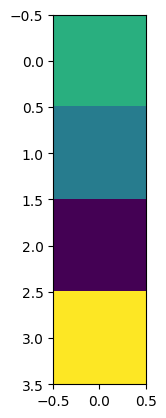

In [ ]:
plt.imshow(test)
plt.show()

In [ ]:
np.allclose(test, 0)

True

# Subspaces

$$ \underset{\text{Column Space}}{C(A)}\;\underset{combination}{\cup}\; \underset{\text{Left Null Space}}{N(A^T)} \text{ is in } \mathbb{R}^m$$

Those are orthogonal, so any vector from column space is orthogonal to any vector from left null space.

In [ ]:
np.linalg.matrix_rank(matrix)

np.int64(2)

Since dim of column space is 2, we can take any 2 independent columns

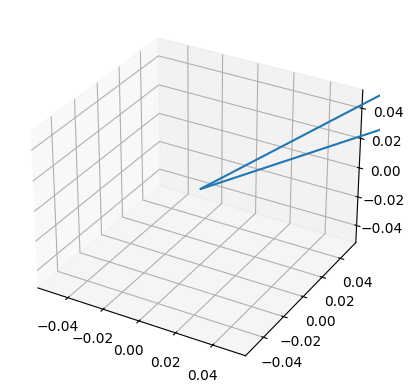

In [ ]:
c1 = matrix[:,1]
c2 = matrix[:,3]

ax = plt.figure().add_subplot(projection = '3d')
ax.quiver(0,0,0,c1[0],c1[1],c1[2])
ax.quiver(0,0,0,c2[0],c2[1],c2[2])

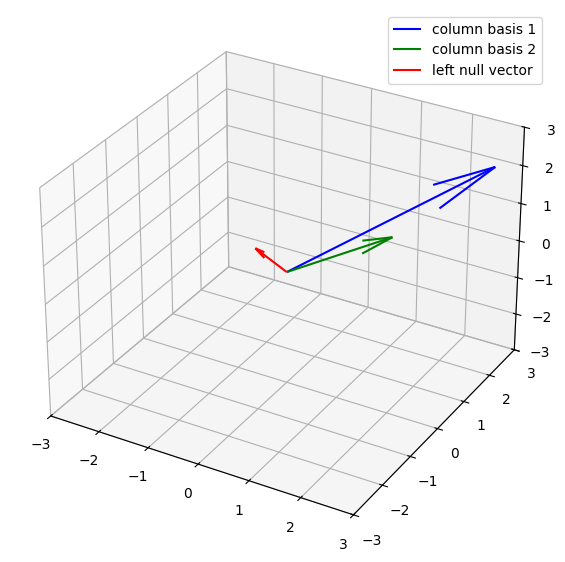

In [ ]:
left_null_space = null_space(matrix.T)
ln = left_null_space[:, 0]

ax = plt.figure(figsize=(7,7)).add_subplot(projection="3d")

ax.quiver(0,0,0, c1[0], c1[1], c1[2], color="b", label="column basis 1")
ax.quiver(0,0,0, c2[0], c2[1], c2[2], color="g", label="column basis 2")
ax.quiver(0,0,0, ln[0], ln[1], ln[2], color="r", label="left null vector")

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_zlim(-3,3)
ax.legend()
plt.show()

We can see that red arrow is kind of orthogonal to 2 vectors from column space

Let's check orthogonality

In [ ]:
c1 @ ln

np.float64(-8.326672684688674e-16)

In [ ]:
c2 @ ln

np.float64(-2.220446049250313e-16)

In [ ]:
matrix.T @ ln

array([-6.10622664e-16, -8.32667268e-16, -1.27675648e-15, -2.22044605e-16])

Lets check if $\mathbb{R}^m$ equals to summed dimensionality of $C(A)$ and $N(A^T)$

In [ ]:
rank = np.linalg.matrix_rank(matrix)

col_dim       = rank
left_null_dim = null_space(matrix.T).shape[1]
M             = matrix.shape[0]

print(col_dim + left_null_dim, "=", M)

3 = 3


$$ \underset{\text{Row Space}}{R(A)}\;\underset{combination}{\cup}\; \underset{\text{Null Space}}{N(A)} \text{ is in } \mathbb{R}^n$$

Here we cant visualize since row vectors lives in $\mathbb{R}^4$ ambient space, but lets check rule

In [ ]:
row_dim = np.ldinalg.matrix_rank(matrix.T)
null_dim = null_space(matrix).shape[1]
N = matrix.shape[1]

print(row_dim + null_dim, "=", N)

4 = 4


in null space we take `shape[1]` because subspace dimension (span dimension) is always count of columns in a basis, not length of a vector.

# Exmaples of the four subspaces

In [ ]:
import numpy as np
from scipy.linalg import null_space

matrix = np.array([[1,2,0],[3,3,-3]])
matrix

array([[ 1,  2,  0],
       [ 3,  3, -3]])

**Dim Column Space**

In [ ]:
np.linalg.matrix_rank(matrix)

np.int64(2)

**Basis Set for Column Space**

In [ ]:
v1 = matrix[:,0]
v2 = matrix[:,1]

column_space = np.column_stack([v1,v2])

np.linalg.matrix_rank(column_space)

np.int64(2)

We still have dim 2 so v1 and v2 present column space

In [ ]:
column_space

array([[1, 2],
       [3, 3]])

**Dim Row Space**

In [ ]:
np.linalg.matrix_rank(matrix.T)

np.int64(2)

Dim of Row Space is 2

**Basis Set for Row Space**

Since dim of row space is 2 and we have only 2 rows, Row Space is same as A

In [ ]:
row_space = matrix
row_space

array([[ 1,  2,  0],
       [ 3,  3, -3]])

**Dim of Left Null Space**

In [ ]:
null_space(matrix.T).shape[1]

0

Dim of Left Null Space is 0

**Basis Set for Left Null Space**

In [ ]:
left_null_space = null_space(matrix.T)
left_null_space

array([], shape=(2, 0), dtype=float64)

**Basis Set for Null Space**

In [ ]:
null_space_ = null_space(matrix)
null_space_

array([[ 0.81649658],
       [-0.40824829],
       [ 0.40824829]])

In [ ]:
matrix@null_space_

array([[-3.33066907e-16],
       [-2.22044605e-16]])

**Dim Null Space**

In [ ]:
null_space_.shape[1]

1

Dim of Null Space is 1

# $Ax = b \text{ and } Ax = 0$

**Does Ax = b have a solution?**

Yes, if:

$$
b \in C(A)
$$

because Ax is a linear combination of the columns of A.
The vector x contains the coefficients that scale and combine the columns of A.
Therefore, b must lie in the column space of A; otherwise, there is no combination of A's columns that can produce b.

$x$ can be any matrix which dimensions fit $A$ right-multiplication, therefore $x$ by its own will never change $A$'s span, it can only scale it.

**Is there an exact solution? If so what $\overset{\wedge}{b}$ should look like to make $Ax = \overset{\wedge}{b}$ solvable?**

$$ \|\|\,\overset{\wedge}{b}-b\,\|\| $$

We're interested in

$$ Ax = 0 $$

So, the null space $x$ of the $A$ matrix, BUT actually in

$$ (A - \lambda I)\,x = 0 $$

This results in scalar vector combinations and those combinations are called Eigenvalue for $(A-\lambda I)$ and Eigenvector for $x$

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_9259/799169942.py:26: SyntaxWarning: invalid escape sequence '\l'
  axs[2].set_title('$A - \lambda I$\n$(Eigenvalue: \lambda)$')


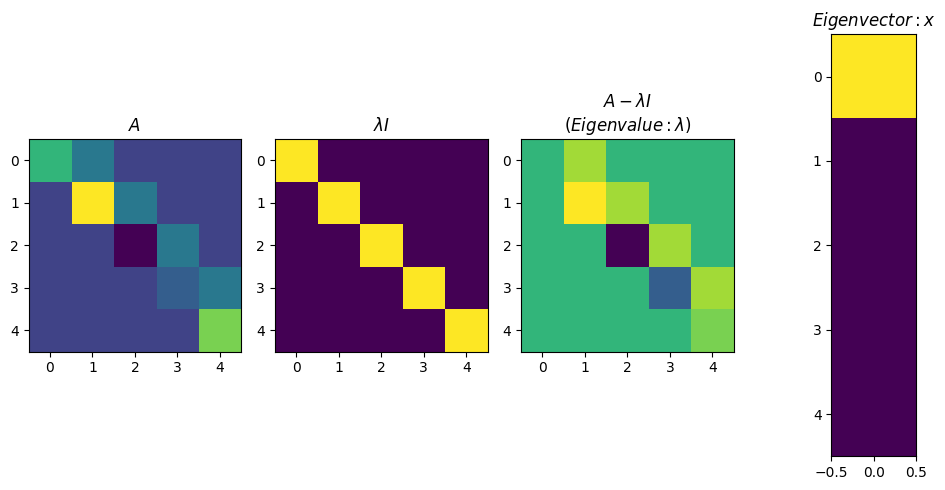

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space

l = 2.3

A = np.array([
    [2.3, 1.0, 0.0, 0.0, 0.0],
    [0.0, 4.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, -1.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.5, 1.0],
    [0.0, 0.0, 0.0, 0.0, 3.0]
])

I = np.eye(5)

_, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(A)
axs[0].set_title('$A$')

axs[1].imshow(l * I)
axs[1].set_title('$\\lambda I$')

axs[2].imshow(A - l * I)
axs[2].set_title('$A - \lambda I$\n$(Eigenvalue: \lambda)$')

eigenvector = null_space(A - l*I)

axs[3].imshow(eigenvector)
axs[3].set_title('$Eigenvector: x$')

plt.tight_layout()
plt.show()

*Based on a notebook of Mike X Cohen. Notebook was modified.*